# RAG System For Intelligent Robotics Course

## Importing modules and Dowload Dataset

In this section we setup all the modules and the dataset for the rag.

In [ ]:
# Dowload all needed modules.
!pip install transformers sentence-transformers faiss-cpu hf_transfer pandas matplotlib seaborn mdclense

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.1 MB/s eta 0:00:00


In [ ]:
# Import all necessary modules.
import json
import os
from mdclense.parser import MarkdownParser
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import time

# Needed for faster dowloads (not sure)
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [ ]:
# Here we download all the necessary files from our git repository.

# Download the chapters and store them into 'data' folder.
!curl -s https://api.github.com/repos/Ultimi-Sumiti/RAG-system/contents/data/raw_data/chapters \
| grep "download_url" \
| cut -d '"' -f 4 \
| xargs -n 1 curl -L -O --create-dirs --output-dir data/raw_data

# Dowload quesions and answers.
!curl -L -O https://raw.githubusercontent.com/Ultimi-Sumiti/RAG-system/main/data/questions_answers.json --output-dir data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5184  100  5184    0     0  19081      0 --:--:-- --:--:-- --:--:-- 19129
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4133  100  4133    0     0  14937      0 --:--:-- --:--:-- --:--:-- 14974
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8822  100  8822    0     0  57801      0 --:--:-- --:--:-- --:--:-- 57660
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1708  100  1708    0     0  10423      0 --:--:-- --:--:-- --:--:-- 10478
  % Total    % Received % Xferd  Average Speed   Tim

In [ ]:
# Uncomment the following lines if you want to store the
# llm model (that we will use later) into your personal gdrive.
# NOTE that the first time you dowload the model, it will take some time.

cache_dir = None
from google.colab import drive
drive.mount('/content/drive')
# Create a cache folder in your Drive.
cache_dir = "/content/drive/MyDrive/hf_model_cache"
os.makedirs(cache_dir, exist_ok=True)
# Set hugging face cache dir.
os.environ["HF_HOME"] = cache_dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Preprocessing: creating the knowledge base

Our dataset is composed by 10 markdown files, each file contains a single chapter.
Those file are notes from the course of Intelligent Robotics (a course from UNIPD).

In this section we perform the following operations:

1. Merge the content of all markdown files into a single variable.
2. Parse the entire document: remove markdown tags and store raw document to disk.
3. Split the raw document into smaller chunks
    - Chunk size = 150 words
    - Overlapping percentage = 10%
4. Store chunks into a json file.

In [ ]:
# Global vars.
RAW_DATA_DIR = "./data/raw_data/"
KB_JSON = "./data/kb_docs.json"

def create_overlapping_chunks(word_list, chunk_size, overlap_pct):
    """ Given a list of strings it returns a list of ovelapping chunks """
    # Calculate the number of overlapping words.
    overlap_count = int(chunk_size * overlap_pct)
    # Create the chunks.
    step = chunk_size - overlap_count
    chunks = [
        word_list[i : i + chunk_size]
        for i in range(0, len(word_list), step)
    ]
    output = ["".join(x + " " for x in ls) for ls in chunks]
    return output

In [ ]:
# Create a list containing the text of each chapter file.
ls = []
for file in os.listdir(RAW_DATA_DIR):
    # File path.
    fp = os.path.join(RAW_DATA_DIR, file)
    # Open file and append content to list.
    with open(fp, 'r') as f:
        t = f.read()
        ls.append(t)

# Merge the content of each chapter into a single string.
text = "".join([x for x in ls])
print("Document lenght (chars):", len(text))

Document lenght (chars): 65374


In [ ]:
# Remove markdown tags from the text.
parser = MarkdownParser()
clean = parser.parse(text)
print("Cleaned document length (chars):", len(clean))
ls_clean = clean.split()
print("Number of words in the document:", len(ls_clean))
# Store cleaned text to disk.
with open("./data/cleaned_raw_text.txt", 'w') as f:
    f.write(clean)

Cleaned document length (chars): 58805
Number of words in the document: 8525


In [ ]:
# Create the chunks.
chunk_size = 150
overlap_pct = 0.1

# Get list of chunks.
ls_docs = create_overlapping_chunks(ls_clean, chunk_size=chunk_size, overlap_pct=overlap_pct)
# Print some stats...
non_overlap = len(ls_clean) // chunk_size
print("Total blocks (non overlapping):", non_overlap)
print("Total blocks (overlapping)", len(ls_docs))

# Store chunks into a json file.
kb = [{"id":i, "text": text} for i, text in enumerate(ls_docs)]
with open(KB_JSON, 'w') as f:
    json.dump(kb, f, indent=4)

Total blocks (non overlapping): 56
Total blocks (overlapping) 64


## Dataset Profiling

In this section we plot some statistics about the our documents.

In [ ]:
# Define raw data input and tokenizer.
file_path = './data/cleaned_raw_text.txt'
model_id = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
with open(file_path, 'r') as f:
    raw_text = f.read()

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# Some basic stats on raw dataset.
char_count = len(raw_text)
words = raw_text.split()
word_count = len(words)
tokens = tokenizer.encode(raw_text, add_special_tokens=False)
total_tokens = len(tokens)
unique_tokens = len(set(tokens))
print(f"### Raw Dataset Stats ###")
print(f"Total Characters: {char_count}")
print(f"Total Words:      {word_count}")
print(f"Total Tokens:     {total_tokens}")
print(f"Vocabulary Size:  {unique_tokens}")

Token indices sequence length is longer than the specified maximum sequence length for this model (12706 > 512). Running this sequence through the model will result in indexing errors


### Raw Dataset Stats ###
Total Characters: 58805
Total Words:      8525
Total Tokens:     12706
Vocabulary Size:  2429



### Chunking Stats ###
Number of chunks: 64


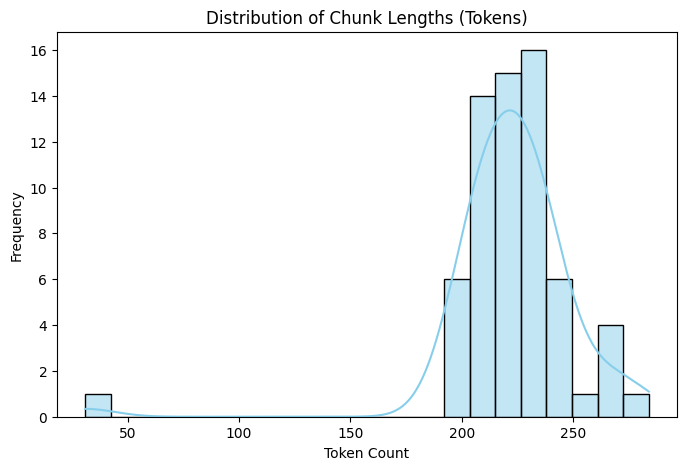

In [ ]:
# Chunks stats.
with open("./data/kb_docs.json", 'r') as f:
    chunks = json.load(f)

chunk_lengths = [len(tokenizer.encode(c["text"])) for c in chunks]
df_chunks = pd.DataFrame(chunk_lengths, columns=['token_length'])
print(f"\n### Chunking Stats ###")
print(f"Number of chunks: {len(chunks)}")

plt.figure(figsize=(8, 5))
sns.histplot(df_chunks['token_length'], kde=True, color='skyblue')
plt.title('Distribution of Chunk Lengths (Tokens)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.show()
plt.close()

The last chunk contains fewer tokens than the others.
Apart from this final chunk, all remaining chunks are nicely distributed.

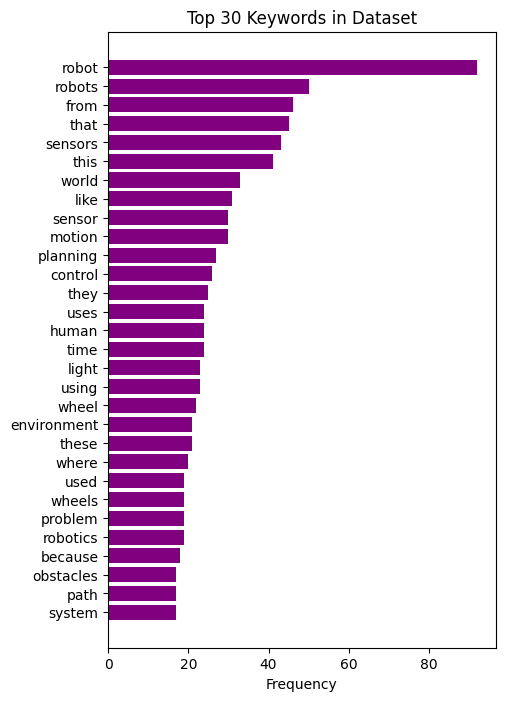

In [ ]:
# Simple cleanup for keyword frequency.
clean_text = re.sub(r'[^\w\s]', '', raw_text.lower())
stop_words = {'the', 'and', 'to', 'of', 'a', 'in', 'is', 'it', 'for', 'on', 'with', 'as'}
filtered_words = [w for w in clean_text.split() if w not in stop_words and len(w) > 3]
word_counts = Counter(filtered_words)

# Display table.
df_freq = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency'])
df_freq = df_freq.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
#print("### Top 30 Keywords in Dataset ###")
#print(df_freq.head(30))

# Print figure.
plt.figure(figsize=(5, 8))
plt.barh(df_freq.head(30)['Word'], df_freq.head(30)['Frequency'], color='purple')
plt.title('Top 30 Keywords in Dataset')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()
plt.close()

We can see that many words are related to *robotics* such that: `robot`, `sensor`, `motion`, `planning`, etc.

## Generate answers

**About the generation process.** We decided to test our model on 50 queries. We've created 5 question for each chapter stored in `./data/raw_data/` folder. Each question is paired with a golden answer. The queries and answers are stored in `./data/questions_answers.json`.

**How did we get the queries/answers?**  The queries were generated by [NotebookLM](https://notebooklm.google/): we gave as input the chapters in `./data/raw_data/` and we asked to provide 5 questions for each one. After that we've asked it to generate the (gold) answers.

**Generation process steps.**

1. Read knowledge base and encode all documents.
2. Create the vector database with the documents embeddings.
3. Load the model (Qwen3-8B) and retreive all queries (from disk).
4. For each query $q$:
    - Encode $q$.
    - Search relevant documents $d$.
    - Create the prompt for the model (using $q$ and $d$).
    - Store the output given by the model.
5. Finally we store the rag answers to disk (`./output_rag_answers.json`).

In [ ]:
# Encode the our knowledge base.
with open(KB_JSON, 'r') as f:
    kb_docs = json.load(f)
encoder = SentenceTransformer(model_id)
docs = [c['text'] for c in kb_docs]
docs_embd = encoder.encode(docs)
print(docs_embd.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(64, 384)
